# Municipal Inequality in COVID-19 Mortality in São Paulo

This project analyzes the spatial distribution of COVID-19 mortality across municipalities in the state of São Paulo. Using publicly available data, we examine how mortality rates evolved over time and how inequality between municipalities changed throughout the pandemic.

The analysis focuses on two main aspects:

1. Comparison of mortality rates across municipalities
2. Measurement of spatial inequality using the Gini coefficient

Understanding these patterns helps reveal how the pandemic affected different regions unevenly.

## Data Sources

COVID-19 case and death data were obtained from the public repository maintained by the Fundação SEADE: https://github.com/seade-R/dados-covid-sp/tree/master

The dataset provides daily counts of confirmed cases and deaths for each municipality in the state of São Paulo.

To enable comparisons between municipalities, data was obtained from the Brazilian Institute of Geography and Statistics (IBGE) from the website: https://cidades.ibge.gov.br/brasil/sintese/sp?indicadores=96385,47001,329756,29167,96386

All datasets used in this analysis are publicly available.

## Data

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np
import seaborn as sns

sns.set_theme(context="talk")

In [2]:
df_covid = pd.read_csv("dados_covid_sp.csv", delimiter=";")
df_covid["datahora"] = pd.to_datetime(df_covid["datahora"])
df_covid.drop(columns=["codigo_ibge", "casos_mm7d", "obitos_mm7d", "pop", "semana_epidem", "casos_novos", "obitos_novos"], inplace=True)

df_covid.rename(columns={"nome_munic": "City", "datahora": "date", "casos": "Cumulative cases", "obitos":"Cumulative deaths"}, inplace=True)
df_covid

,City,date,Cumulative cases,Cumulative deaths
0,Adamantina,2020-02-25,0,0
1,Adolfo,2020-02-25,0,0
2,Aguaí,2020-02-25,0,0
3,Águas da Prata,2020-02-25,0,0
4,Águas de Lindóia,2020-02-25,0,0
...,...,...,...,...
880493,Ignorado,2023-11-14,371,0
880494,Ignorado,2023-11-15,310,1
880495,Ignorado,2023-11-16,298,1
880496,Ignorado,2023-11-17,279,0


In [3]:
df_pop=pd.read_html("ibge_sp.html")[0]

df_pop.drop(index=645, columns="Gentílico", inplace=True)
df_pop.columns = ["City", "HDI", "GDP per capita", "Population", "Area", "Density"]


df_pop["HDI"] = df_pop["HDI"].astype(float)/1e3
df_pop["GDP per capita"] = df_pop["GDP per capita"].str.replace("R$", "").str.replace(",", ".").astype(float)
df_pop["Population"] = df_pop["Population"].str.replace("pessoas", "").astype(float)
df_pop["Area"] = df_pop["Area"].str.replace("km²", "").str.replace(",", ".").astype(float)
df_pop["Density"] = df_pop["Density"].str.replace("habitante por quilômetro quadrado", "").str.replace(",", ".").astype(float)

df_pop

,City,HDI,GDP per capita,Population,Area,Density
0,Adamantina,0.790,49179.66,34687.0,411.987,84.19
1,Adolfo,0.730,49478.96,4351.0,211.055,20.62
2,Aguaí,0.715,55308.14,32072.0,474.554,67.58
3,Águas da Prata,0.781,36960.06,7369.0,142.673,51.65
4,Águas de Lindóia,0.745,44680.12,17930.0,60.126,298.21
...,...,...,...,...,...,...
640,Vista Alegre do Alto,0.744,87056.50,8109.0,95.429,84.97
641,Vitória Brasil,0.725,35942.63,1794.0,49.832,36.00
642,Votorantim,0.767,40724.92,127923.0,184.186,694.53
643,Votuporanga,0.790,47418.12,96634.0,420.703,229.70


In [4]:
def classifica_idhm(idhm):
    if idhm < .55:
        return "Low"
    elif idhm < .699:
        return "Medium"
    elif idhm < .799:
        return "High"
    return "Very High"


df_pop["Class HDI"] = df_pop["HDI"].apply(classifica_idhm)

df_pop

,City,HDI,GDP per capita,Population,Area,Density,Class HDI
0,Adamantina,0.790,49179.66,34687.0,411.987,84.19,High
1,Adolfo,0.730,49478.96,4351.0,211.055,20.62,High
2,Aguaí,0.715,55308.14,32072.0,474.554,67.58,High
3,Águas da Prata,0.781,36960.06,7369.0,142.673,51.65,High
4,Águas de Lindóia,0.745,44680.12,17930.0,60.126,298.21,High
...,...,...,...,...,...,...,...
640,Vista Alegre do Alto,0.744,87056.50,8109.0,95.429,84.97,High
641,Vitória Brasil,0.725,35942.63,1794.0,49.832,36.00,High
642,Votorantim,0.767,40724.92,127923.0,184.186,694.53,High
643,Votuporanga,0.790,47418.12,96634.0,420.703,229.70,High


In [5]:
df = pd.merge(df_pop, df_covid, on="City", how="inner")

## Metric Construction

To enable meaningful comparisons between municipalities of different population sizes, we compute normalized indicators.

The main indicator used in this analysis is the COVID-19 mortality rate per 100,000 inhabitants:

Mortality Rate = (Deaths / Population) × 100,000

This metric allows us to compare the severity of the pandemic across municipalities regardless of population size.



In [6]:
df["Mortality rate"] = df["Cumulative deaths"] / df["Population"] * 1e5

# df

In [7]:
# Remove cities w/ less than 20000 habitants. Very small municipalities may exhibit highly volatile mortality rates due to small population denominators

df = df[df["Population"] >= 2e4]

In [8]:
# Export dataset
df.to_csv("Covid_FinalDataset.csv", index=False)

In [9]:
latest_date = pd.Timestamp("2022-12-31")

snapshot = df[df["date"] == latest_date]
snapshot.sort_values("HDI", ascending=False, inplace=True)

snapshot.describe()

/tmp/ipykernel_485956/1671988158.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snapshot.sort_values("HDI", ascending=False, inplace=True)


,HDI,GDP per capita,Population,Area,Density,date,Cumulative cases,Cumulative deaths,Mortality rate
count,252.000000,252.000000,2.520000e+02,252.000000,252.000000,252,2.520000e+02,252.000000,252.000000
mean,0.759464,69465.124643,1.639645e+05,500.884821,788.583968,2022-12-31 00:00:00,2.272809e+04,657.888889,388.894921
min,0.667000,13549.010000,2.006100e+04,15.331000,14.250000,2022-12-31 00:00:00,1.047000e+03,41.000000,134.836730
25%,0.739000,42023.955000,3.171575e+04,182.082000,71.055000,2022-12-31 00:00:00,5.905000e+03,118.500000,325.229605
50%,0.762000,55980.860000,5.412400e+04,413.073500,156.425000,2022-12-31 00:00:00,9.843000e+03,201.000000,382.617494
75%,0.780000,74204.207500,1.245498e+05,706.977750,422.377500,2022-12-31 00:00:00,2.133550e+04,499.500000,455.810283
max,0.862000,606740.730000,1.145200e+07,1978.795000,13416.810000,2022-12-31 00:00:00,1.139273e+06,44352.000000,703.872506
std,0.030284,60384.816910,7.337928e+05,392.734536,1970.679337,NaN,7.483869e+04,2866.876138,102.547588


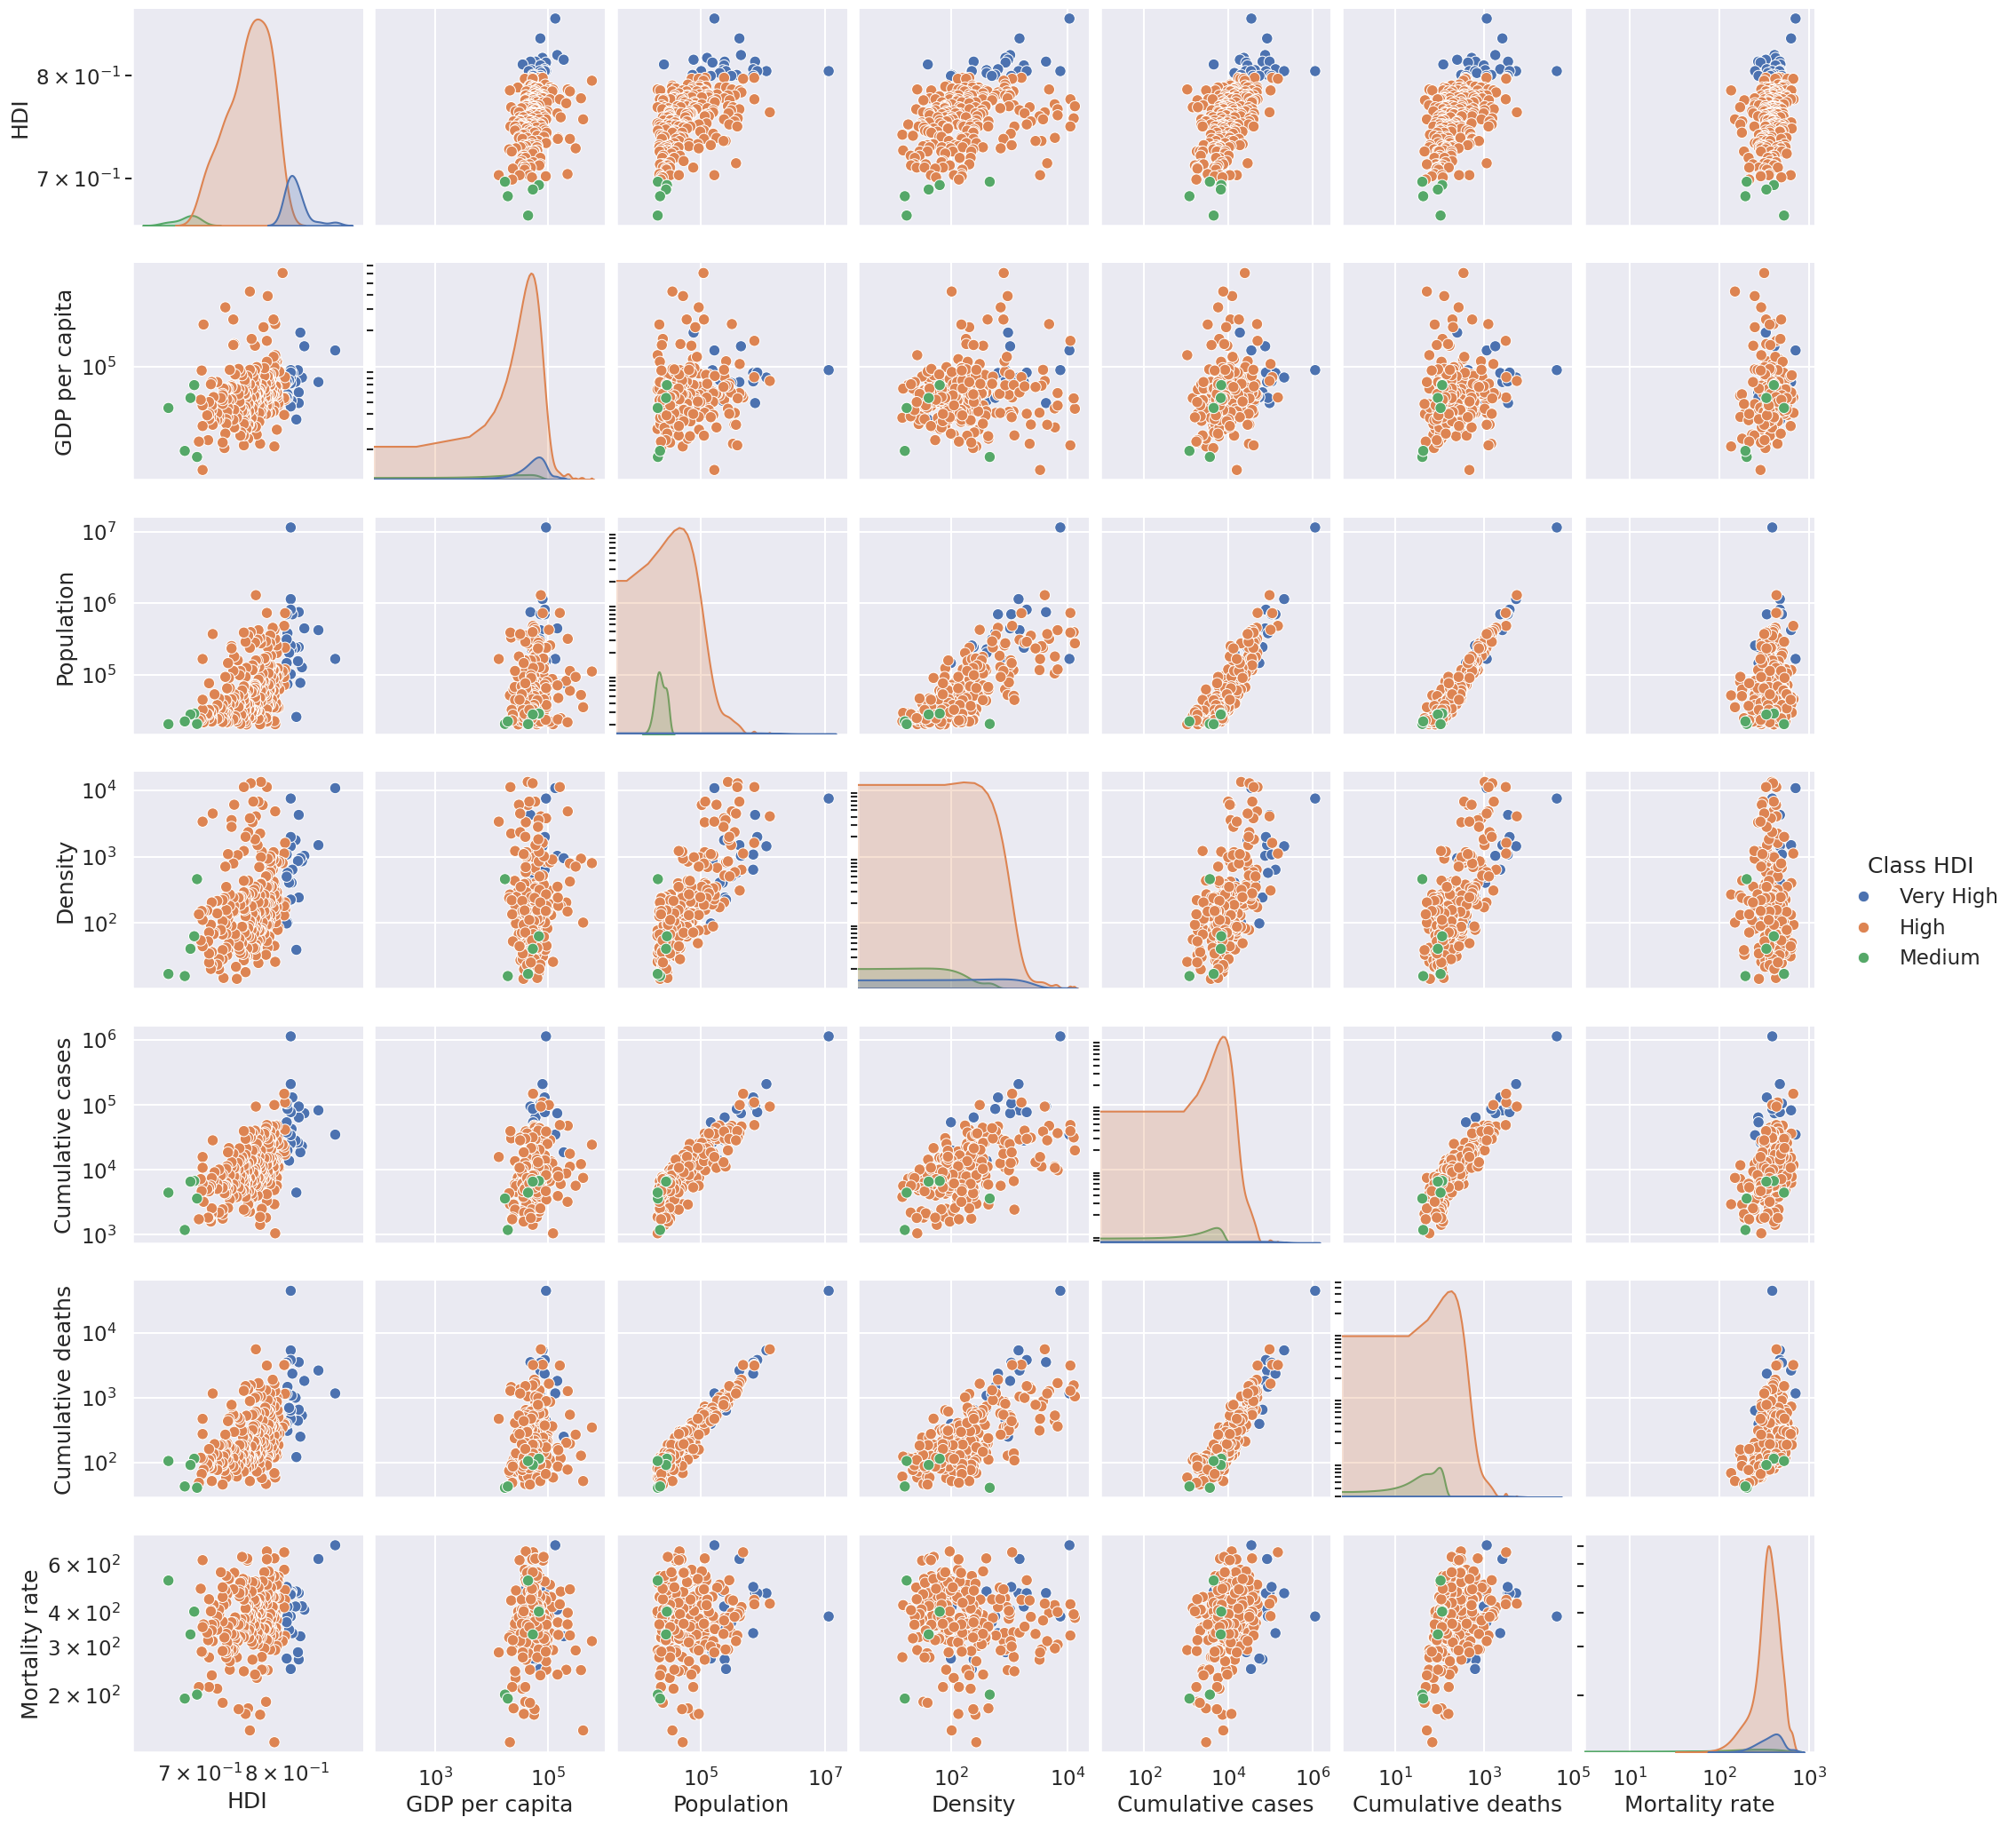

In [10]:
vars = ['HDI', 'GDP per capita', 'Population', 'Density', 'Cumulative cases', 'Cumulative deaths', 'Mortality rate']

pp = sns.pairplot(snapshot, vars=vars, hue="Class HDI", height=3)

for ax in pp.axes.flat:
    ax.set(xscale="log", yscale="log")

# log_columns = ['Pop', "Dens. demografica", "PIB per capita"]

# for ax in pp.axes.flat:
#     if ax.get_xlabel() in log_columns:
#         ax.set(xscale="log")

#     if ax.get_ylabel() in log_columns:
#         ax.set(yscale="log")

Text(0.5, 1.0, 'Correlation Between Municipal Indicators (log scale)')

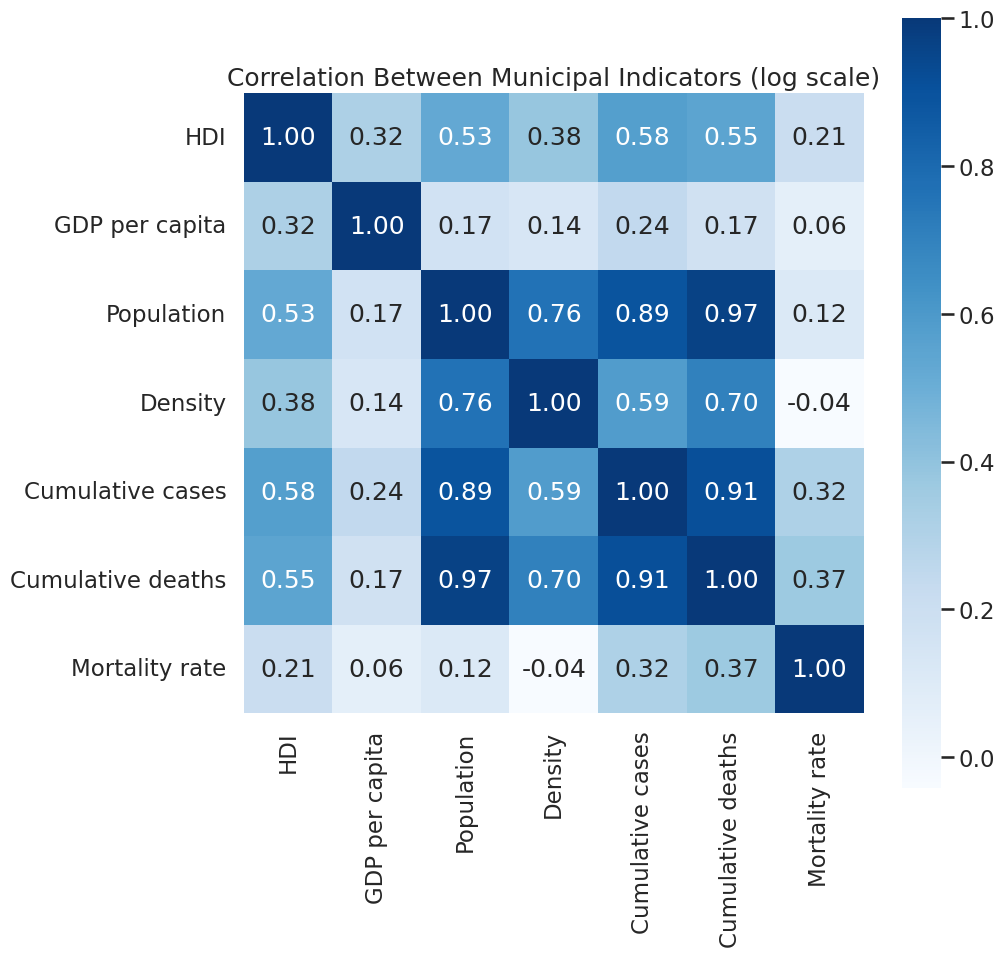

In [11]:
df_log = snapshot[vars].apply(np.log10)
corr = df_log.corr()
# corr = snapshot[vars].corr()

f, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0.5,
    square=True, 
    ax=ax
)

ax.set_title("Correlation Between Municipal Indicators (log scale)")

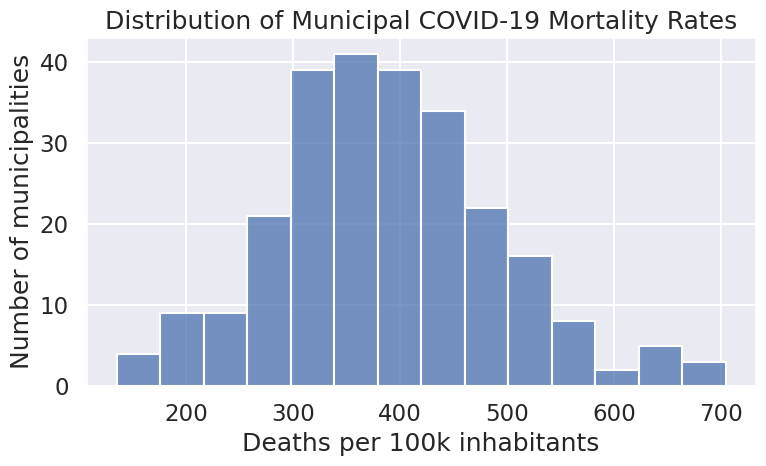

In [12]:
f, ax = plt.subplots(figsize=(8,5))
sns.histplot(snapshot, x="Mortality rate", ax=ax)
# 
ax.set_title("Distribution of Municipal COVID-19 Mortality Rates")
ax.set_xlabel("Deaths per 100k inhabitants")
ax.set_ylabel("Number of municipalities")

f.tight_layout()

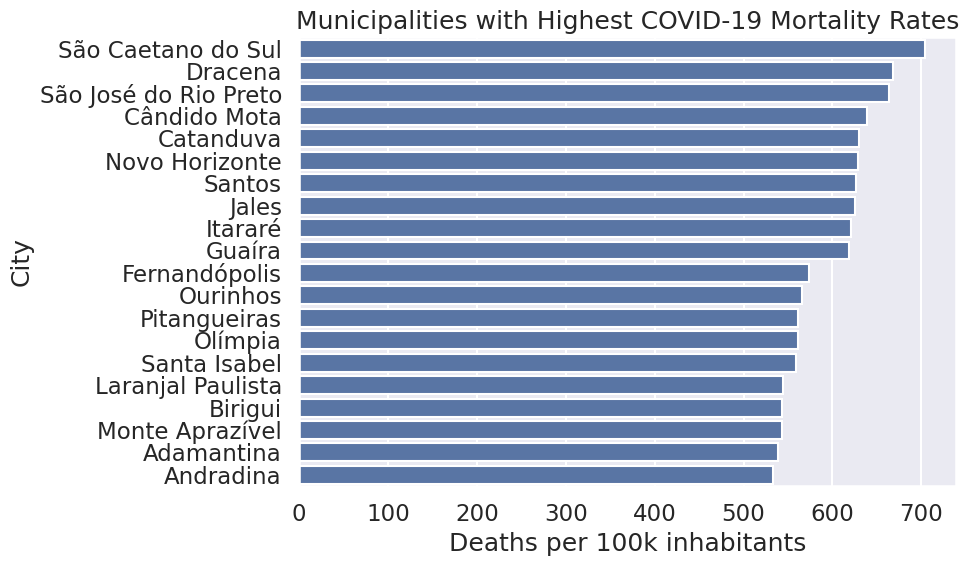

In [13]:
top_mortality = (
    snapshot
    .sort_values("Mortality rate", ascending=False)
    .head(20)
)


f, ax = plt.subplots(figsize=(10,6))
sns.barplot(top_mortality, x = "Mortality rate", y="City")
ax.set_xlabel("Deaths per 100k inhabitants")
ax.set_title("Municipalities with Highest COVID-19 Mortality Rates")

f.tight_layout()

Text(0.5, 1.0, 'Municipalities with Highest COVID-19 Deaths')

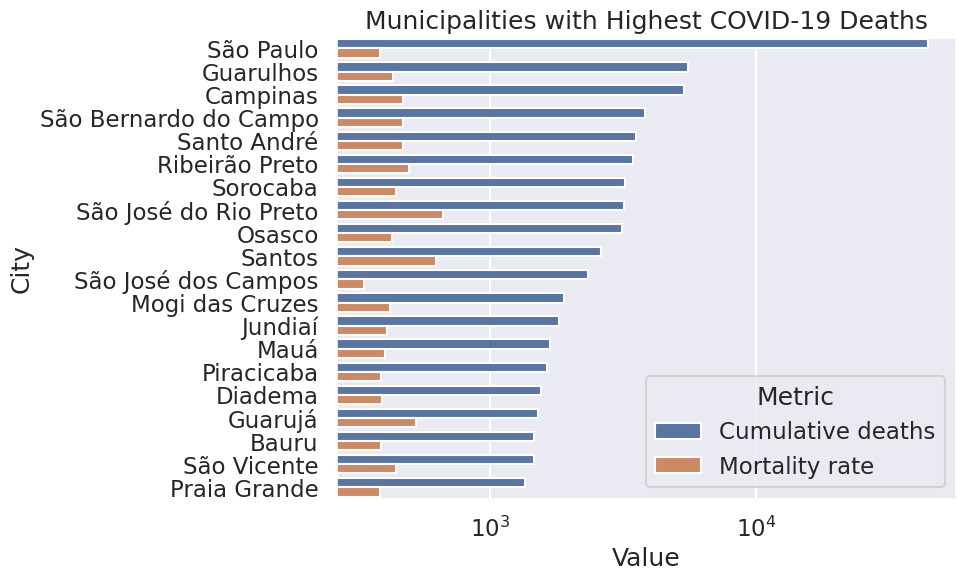

In [14]:
top_deaths = (
    snapshot
    .sort_values("Cumulative deaths", ascending=False)
    .head(20)
)


top_deaths = top_deaths.melt(
    id_vars="City",
    value_vars=["Cumulative deaths", "Mortality rate"],
    var_name="Metric",
    value_name="Value"
)

f, ax = plt.subplots(figsize=(8,6))

sns.barplot(top_deaths, x = "Value", y="City", hue="Metric", ax=ax)

ax.set_xscale("log")

# ax.set_xlabel("Deaths per 100k inhabitants")
ax.set_title("Municipalities with Highest COVID-19 Deaths")



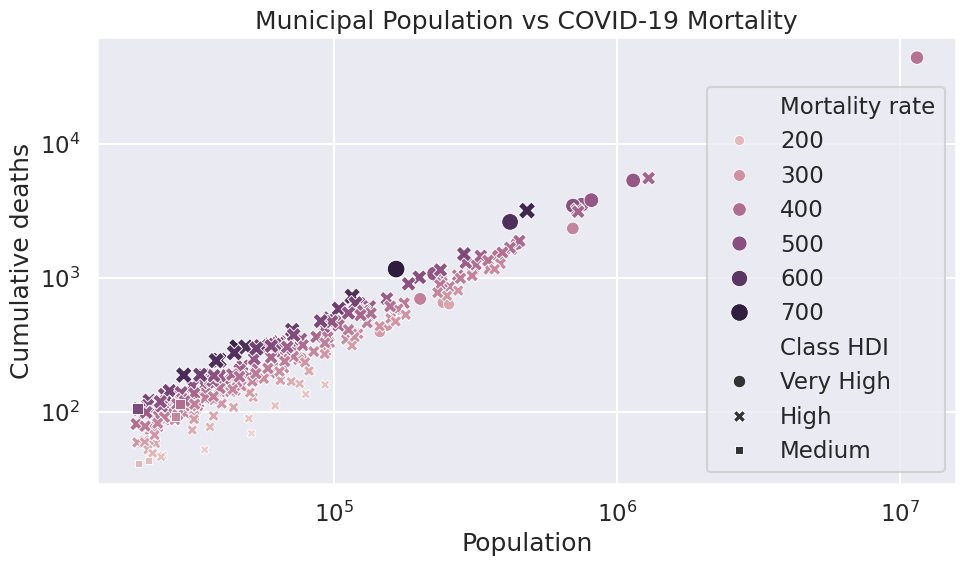

In [15]:
f, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(snapshot, x="Population", y="Cumulative deaths", ax=ax, hue="Mortality rate", size="Mortality rate", style="Class HDI")

ax.loglog()

ax.set_title("Municipal Population vs COVID-19 Mortality")

ax.legend(loc=4)
f.tight_layout()

In [16]:
# f, ax = plt.subplots(figsize=(8,6))

# l1 = ax.scatter(snapshot["Population"], snapshot["Cumulative deaths"], 
#                 # s=snapshot["obitos"], 
#                 s=60, c=snapshot["Mortality rate"], alpha=0.6)

# f.colorbar(l1, label="Deaths per 100k")

# ax.loglog()

# ax.set_xlabel("Municipal population")
# ax.set_ylabel("Total Deaths")

# ax.set_title("Municipal Population vs COVID-19 Mortality")

# f.tight_layout()

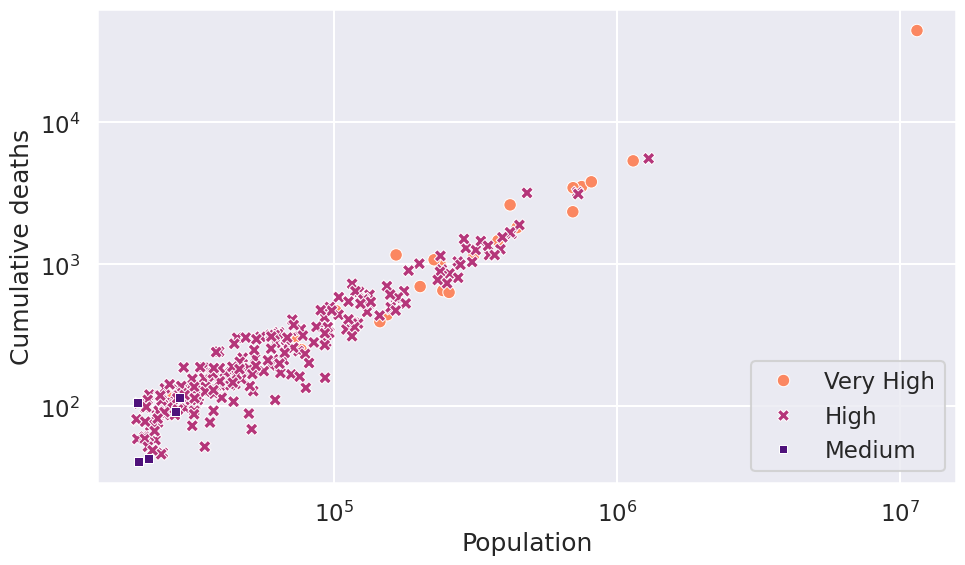

In [17]:
f, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=snapshot, x="Population", y="Cumulative deaths", style="Class HDI", hue="Class HDI", ax=ax, palette="magma_r")
ax.legend(loc=4)

ax.loglog()

f.tight_layout()

# # # f.colorbar(teste)

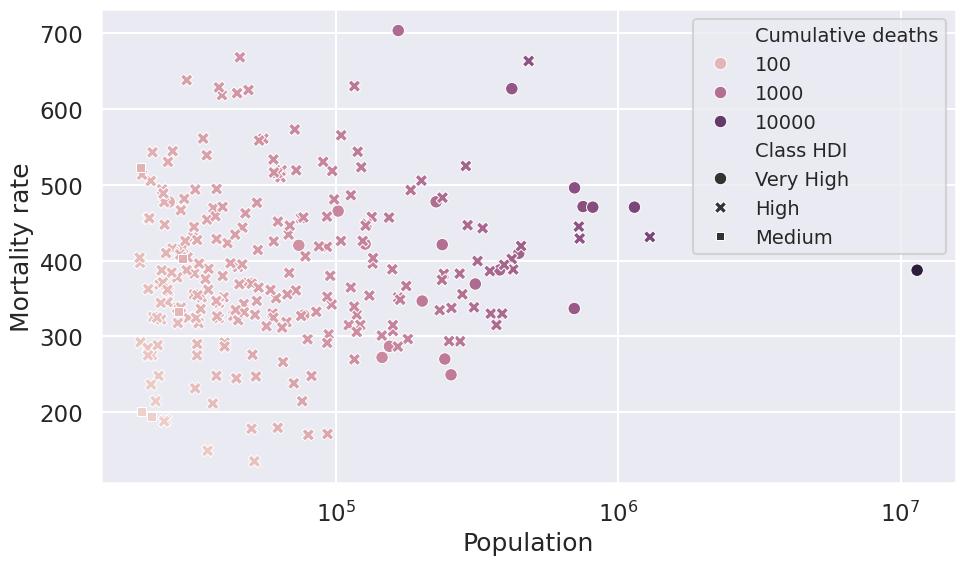

In [18]:
f, ax = plt.subplots(figsize=(10,6))


sns.scatterplot(data=snapshot, x="Population", y="Mortality rate", hue="Cumulative deaths", hue_norm=matplotlib.colors.LogNorm(), style="Class HDI",)

# l1 = ax.scatter(snapshot["Population"], snapshot["Mortality rate"], 
#                 # s=snapshot["obitos"]*500/snapshot["obitos"].max() + 50, 
#                 s=80, 
#                 c=snapshot["Cumulative deaths"], alpha=0.6, 
#                 norm=matplotlib.colors.LogNorm(),
#                 cmap="magma"
#                 # edgecolors="none"
#                 )

# f.colorbar(l1, label="Total Deaths")

ax.set_xscale("log")
ax.legend(loc=1, fontsize=14)

# ax.set_xlabel("Municipal population")
# ax.set_ylabel("Deaths per 100k")

# ax.set_title("Municipal Population vs COVID-19 Mortality")

f.tight_layout()

In [19]:
# f, ax = plt.subplots(figsize=(8,6))

# l1 = ax.scatter(snapshot["Population"], snapshot["Mortality rate"], 
#                 # s=snapshot["obitos"]*500/snapshot["obitos"].max() + 50, 
#                 s=80, 
#                 c=snapshot["Cumulative deaths"], alpha=0.6, 
#                 norm=matplotlib.colors.LogNorm(),
#                 cmap="magma"
#                 # edgecolors="none"
#                 )

# f.colorbar(l1, label="Total Deaths")

# ax.set_xscale("log")


# ax.set_xlabel("Municipal population")
# ax.set_ylabel("Deaths per 100k")

# ax.set_title("Municipal Population vs COVID-19 Mortality")

# f.tight_layout()

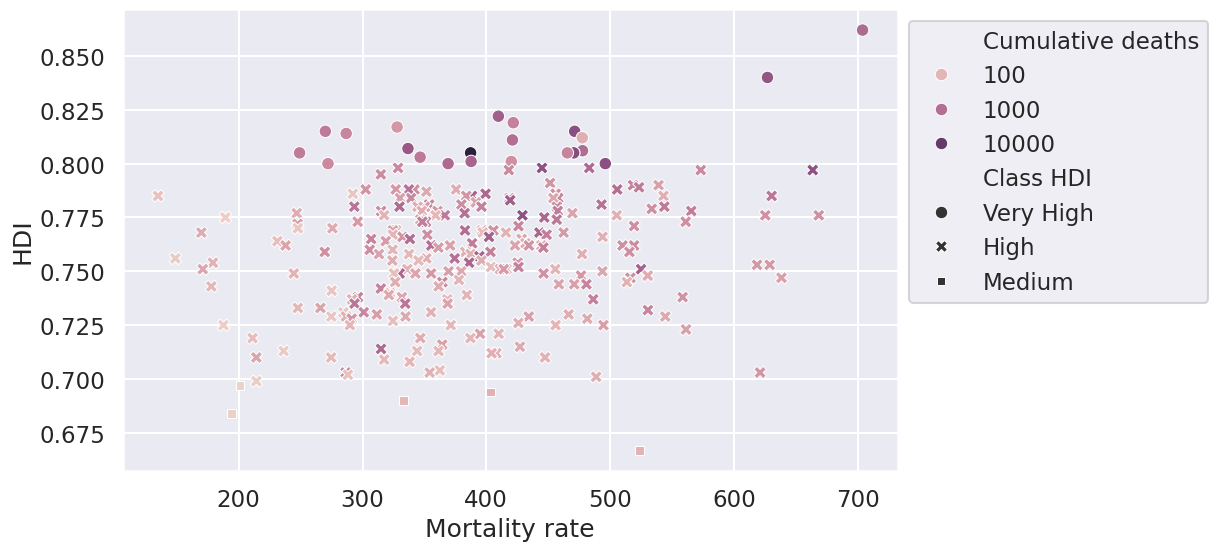

In [20]:
f, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=snapshot, x="Mortality rate", y="HDI", style="Class HDI", hue="Cumulative deaths",  hue_norm=matplotlib.colors.LogNorm(), ax=ax)
ax.legend(bbox_to_anchor=(1, 1))

# # # f.colorbar(teste)

In [21]:
def gini(x):
    x = np.array(x, dtype=float)
    
    if np.amin(x) < 0:
        x -= np.amin(x)
    
    x += 1e-9  # evitar zeros
    
    x = np.sort(x)
    n = len(x)
    
    index = np.arange(1, n + 1)
    
    return (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x))

In [22]:
gini_series = (
    df.groupby("date")["Mortality rate"]
    .apply(gini)
)

gini_series

date
2020-02-25    0.000000
2020-02-26    0.000000
2020-02-27    0.000000
2020-02-28    0.000000
2020-02-29    0.000000
                ...   
2023-11-14    0.145226
2023-11-15    0.145218
2023-11-16    0.145216
2023-11-17    0.145227
2023-11-18    0.145227
Name: Mortality rate, Length: 1363, dtype: float64

<Axes: xlabel='date', ylabel='Mortality rate'>

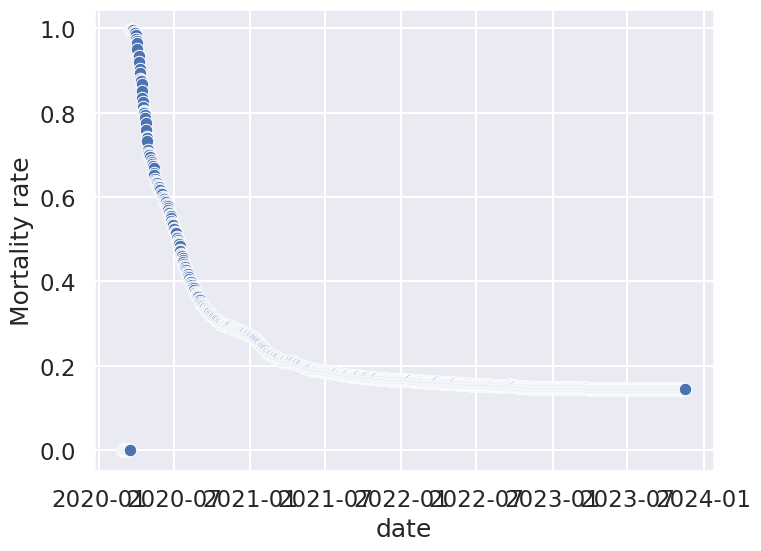

In [23]:
f, ax = plt.subplots(figsize=(8,6))

sns.scatterplot(data=gini_series)

# ax.scatter(.index, gini_series.values)

Text(0.5, 0, 'Date')

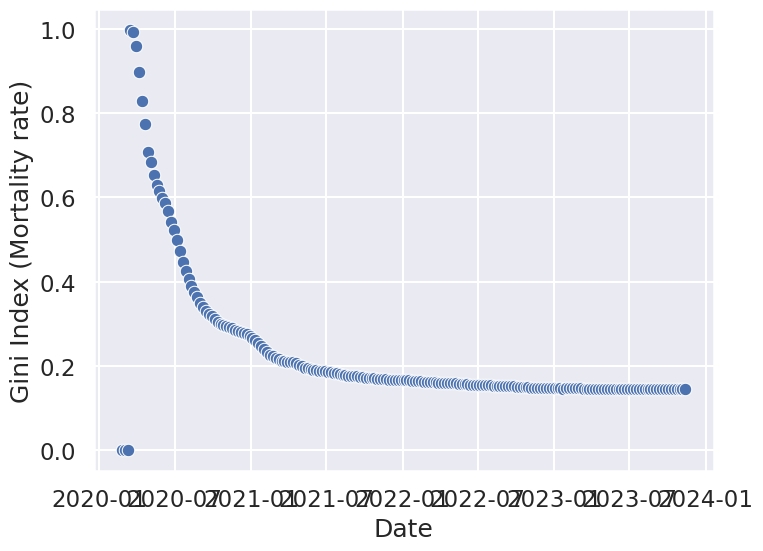

In [24]:
df["week"] = df["date"].dt.to_period("W").dt.start_time

gini_series = (
    df.groupby("week")["Mortality rate"]
    .apply(gini)
)



f, ax = plt.subplots(figsize=(8,6))

# ax.scatter(gini_series.index, gini_series.values)
sns.scatterplot(data=gini_series, ax=ax)
ax.set_ylabel("Gini Index (Mortality rate)")
ax.set_xlabel("Date")


In [25]:
df_day = df[df["date"] == "2021-12-31"]
df_day = df_day.sort_values("Mortality rate")

df_day["cum_municipalities"] = np.arange(1, len(df_day)+1) / len(df_day)

total = df_day["Mortality rate"].sum()
df_day["cum_mortality"] = df_day["Mortality rate"].cumsum() / total


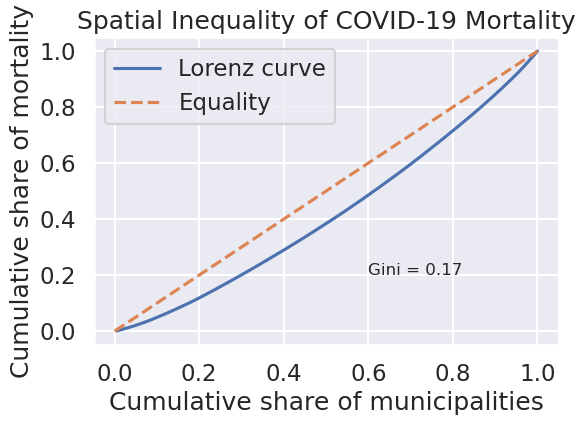

In [26]:
plt.figure(figsize=(6,4))

plt.plot(
    df_day["cum_municipalities"],
    df_day["cum_mortality"],
    label="Lorenz curve"
)

plt.plot([0,1],[0,1], linestyle="--", label="Equality")

plt.xlabel("Cumulative share of municipalities")
plt.ylabel("Cumulative share of mortality")

plt.title("Spatial Inequality of COVID-19 Mortality")


g = gini(df_day["Mortality rate"])
plt.text(
    0.6,
    0.2,
    f"Gini = {g:.2f}",
    fontsize=12
)

plt.legend()

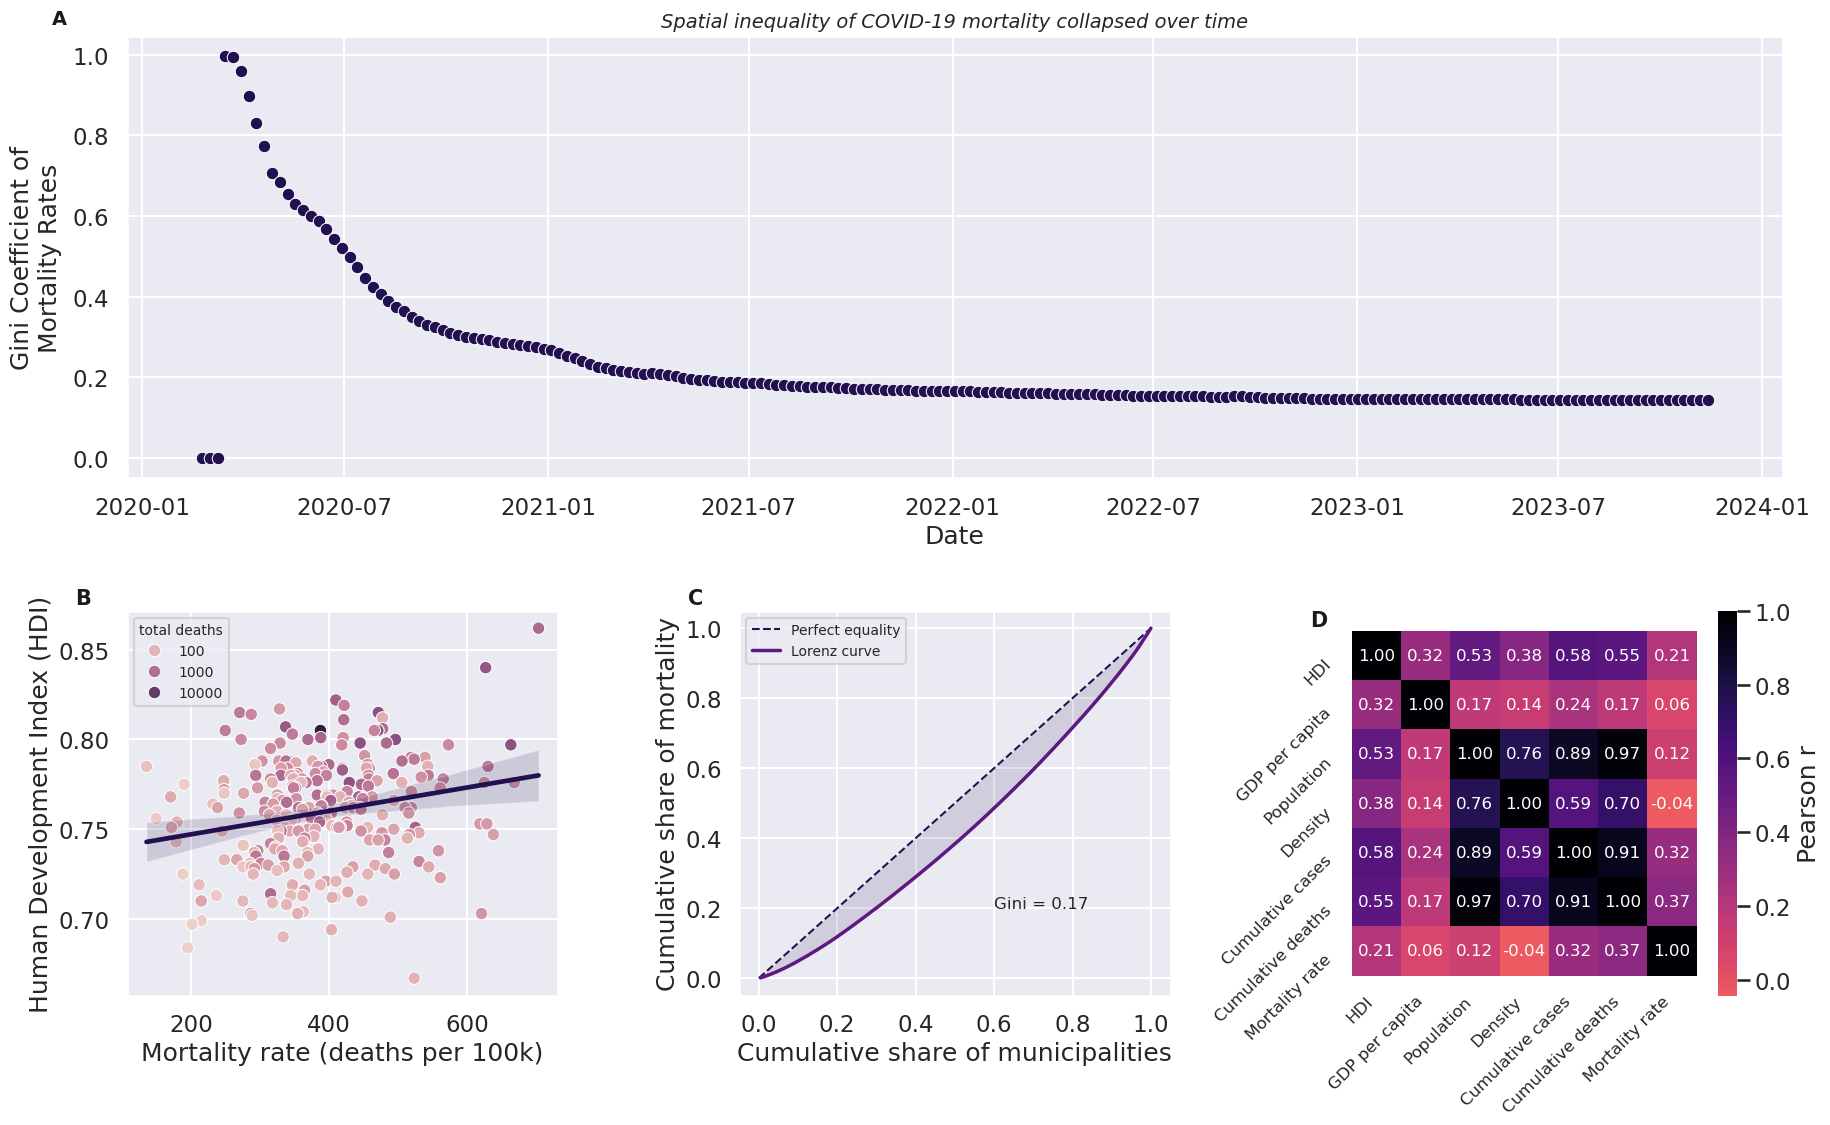

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(
    2, 3,
    figure=fig,
    left=0.06, right=0.98, top=0.87, bottom=0.07,
    hspace=0.32, wspace=0.42,
    height_ratios=[1.15, 1],
)
# cmap = plt.cm.get_cmap('magma')

sns.set_palette("magma")


# =============================================================================
# PANEL A — Gini coefficient over time
# =============================================================================
ax_a = fig.add_subplot(gs[0, 0:3])

sns.scatterplot(data=gini_series, ax=ax_a)
# ax_a.text(gini_series.index[-10], gini_series[-10] + 0.04,
#           f"Gini ≈ {np.round(gini_series[-1], 2)}\n(burden spread\nstatewide)",
#           color="k", fontsize=8.5, va="bottom", ha="right")
# ax_a.annotate("",
#               xy=(gini_series.index[-5], gini_series[-5]),
#               xytext=(gini_series.index[-10], gini_series[-10] + 0.04),
#               arrowprops=dict(arrowstyle="->", color="k", lw=1))


ax_a.set_xlabel("Date")
ax_a.set_ylabel("Gini Coefficient of\nMortality Rates",labelpad=8)

ax_a.text(-0.045, 1.06, "A", transform=ax_a.transAxes,
          fontsize=14, fontweight="bold", color="k", va="top")
ax_a.set_title("Spatial inequality of COVID-19 mortality collapsed over time",
               fontsize=14, style="italic")




# =============================================================================
# PANEL B — Mortality rate vs HDI scatter
# =============================================================================

ax_b = fig.add_subplot(gs[1, 0])


sns.scatterplot(data=snapshot, x="Mortality rate", y="HDI", hue="Cumulative deaths",  hue_norm=matplotlib.colors.LogNorm(), ax=ax_b)
sns.regplot(data=snapshot, x="Mortality rate", y="HDI", scatter=False, ax=ax_b)

ax_b.legend(loc=2, title = "total deaths", fontsize=10, title_fontsize=10)

ax_b.set_ylabel("Human Development Index (HDI)")
ax_b.set_xlabel("Mortality rate (deaths per 100k)")
ax_b.text(-0.12, 1.06, "B", transform=ax_b.transAxes,
          fontsize=15, fontweight="bold", color="k", va="top")
# ax_b.set_title("HDI explains little of per-capita mortality",
#                fontsize=11, color="k", loc="left", pad=10, style="italic")

# =============================================================================
# PANEL C — Lorenz curve
# =============================================================================

ax_c = fig.add_subplot(gs[1, 1])

ax_c.plot([0, 1], [0, 1], linewidth=1.5, linestyle="--", label="Perfect equality", zorder=2)
ax_c.plot(df_day["cum_municipalities"], df_day["cum_mortality"], linewidth=2.5, label="Lorenz curve", zorder=3)


ax_c.fill_between(df_day["cum_municipalities"], df_day["cum_mortality"], df_day["cum_municipalities"],
                  alpha=0.13, zorder=1)


ax_c.set_xlabel("Cumulative share of municipalities")
ax_c.set_ylabel("Cumulative share of mortality")
ax_c.legend(fontsize=10,loc=2)

ax_c.text(-0.12, 1.06, "C", transform=ax_c.transAxes,
          fontsize=15, fontweight="bold", color="k", va="top")
# ax_c.set_title("Even at end-2021, the mortality burden remained unequal",
            #    fontsize=11, color="k", loc="left", pad=10, style="italic")

g = gini(df_day["Mortality rate"])
ax_c.text(
    0.6,
    0.2,
    f"Gini = {g:.2f}",
    fontsize=12
)



# =============================================================================
# PANEL D — Correlation heatmap (lower triangle)
# =============================================================================
ax_d = fig.add_subplot(gs[1, 2])

df_log = snapshot[vars].apply(np.log10)
corr = df_log.corr()
# corr = snapshot[vars].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 12},
    cmap="magma_r",
    center=0.2,
    square=True, 
    ax=ax_d, 
    cbar=True, 
    cbar_kws={"label": "Pearson r"}
)

ax_d.set_xticklabels(ax_d.get_xticklabels(), rotation=45, ha="right", fontsize=12)
ax_d.set_yticklabels(ax_d.get_yticklabels(), rotation=45, va="top", fontsize=12)

ax_d.text(-0.12, 1.06, "D", transform=ax_d.transAxes,
          fontsize=15, fontweight="bold", color="k", va="top")


# fig.savefig("COVID.png", dpi=150, transparent=False)